# **Stellar Spectrum Reduction**

Code component of Question 4 of ASTR4004 Problem Set 2. See assignment write-up for full answer to Question 4.

**Veloce is a high-resolution echelle spectrograph. The `flat.fits` and `moon.fits` in `data` contain the same $4112\times 385$ pixel detector region around the CaII triplet ($\sim 851\to 871\,\mathrm{nm}$). The dispersion direction is vertical and the cross-dispersion direction, horizontal. The central science fibres are bounded by two low-illumination gaps; the curves following these gaps are the *tramlines*. Signal from neighbouring spectra orders have been set to zero. You may assume that the distance between the two tramlines is constant.**

## **Determine the Tramlines**

**Use the flat-field image to determine the tramline positions as a function of dispersion pixel and fit an appropriate smooth function. Briefly explain your approach and plot the flat with your fitted tramlines overlaid.**

Import necessary packages.

In [156]:
# packages handling arrays
import numpy as np
import pandas as pd
# package for data visualisation
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm # for log cmaps
from matplotlib.colors import LinearSegmentedColormap
cmap_colours = ["mediumvioletred", "darkred"]
cmap = LinearSegmentedColormap.from_list(
    "cmap",
    ["white", cmap_colours[0], cmap_colours[1]]
) # set standard cmap
# astropy for handling data in .fits format
from astropy.io import fits
# packages for model fitting
import scipy as sp
import emcee as mc
# functions to format math in outputs
from IPython.display import display, Math

Read in and plot `flat.fits`.

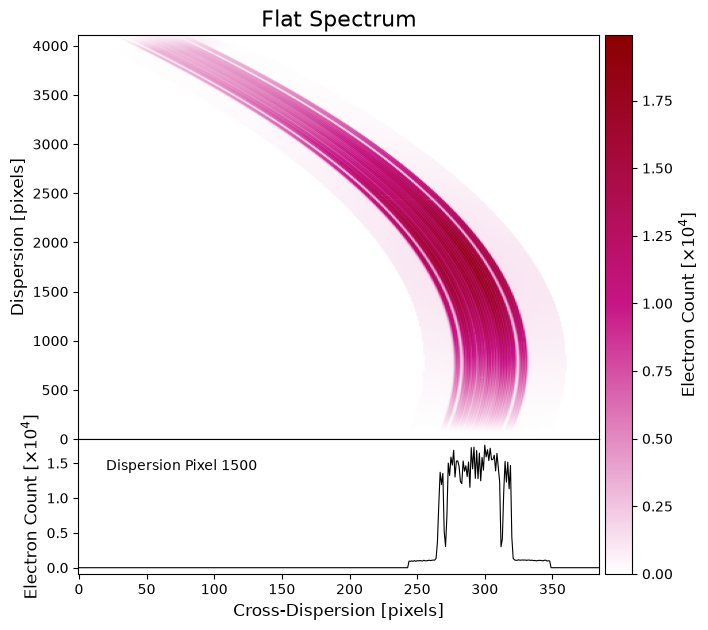

In [157]:
# read-in to file (containing header/metadata)
flat_file = fits.open("data/q4_flat.fits")
# extract data
flat = np.array(flat_file[0].data)

fig, axs = plt.subplots(2, 1, figsize=(8, 7), sharex=True, sharey=False, gridspec_kw={"height_ratios": [3, 1], "hspace": 0})

ax = axs[0] # top panel (full flat)
image = ax.imshow(flat*1e-4, cmap=cmap, origin="lower", aspect="auto")
ax.set_title("Flat Spectrum", fontsize=16)
ax.set_xlabel("Cross-Dispersion [pixels]", fontsize=12)
ax.set_ylabel("Dispersion [pixels]", fontsize=12)

ax = axs[1] # bottom panel (spectrum extraction at pixel=1500)
ax.plot(np.arange(len(flat[1500,:])), np.array(flat[1500,:])*1e-4, c="black", lw=0.8)
ax.text(20, 1.4, "Dispersion Pixel 1500", c="black")
ax.set_xlabel("Cross-Dispersion [pixels]", fontsize=12)
ax.set_ylabel(r"Electron Count [$\times 10^{4}$]", fontsize=12)
cbar = fig.colorbar(image, ax=axs, pad=0.01)
cbar.set_label(r"Electron Count [$\times 10^{4}$]", fontsize=12)

plt.show()

Use `scipy.signal.find_peaks()` to determine the indices of tramlines.

In [158]:
first_peak = []
second_peak = []

for i in np.arange(flat.shape[0]): # iterate over every dispersion pixel

    # extract cross-dispersion spectrum for each dispersion pixel
    spec = np.array(flat[i,:])

    # define threshold cut to isolate signal for peaks detection
    spec_max = np.nanmax(spec) # spectrum max intensity
    noise_thres = 1000 # electron count minimum to be not noise
    if spec_max < noise_thres:
        first_peak.append(np.nan)
        second_peak.append(np.nan)
        continue
    detect_thres = 0.5 # pixel must have 50% of spectrum max intensity
    valid_pixels = (np.where(spec > spec_max*detect_thres))[0]
    if len(valid_pixels) < 45: # detected signal must be at least 100 pixels wide
        first_peak.append(np.nan)
        second_peak.append(np.nan)
        continue
    signal = spec[valid_pixels[1]:valid_pixels[-1]]
    peaks = np.array((sp.signal.find_peaks(-signal, distance=25))[0]) + valid_pixels[1]
    if len(peaks) != 2: # must find exactly 2 peaks
        first_peak.append(np.nan)
        second_peak.append(np.nan)
        continue
    first_peak.append(peaks[0]) # left tramline
    second_peak.append(peaks[1]) # right tramline

tramlines = pd.DataFrame({
    "left": np.array(first_peak), # x-pos left tramline
    "right": np.array(second_peak), # y-pos right tramline
    "disp": np.arange(flat.shape[0]) # y-pos
})

Overplot peaks detection for clarity.

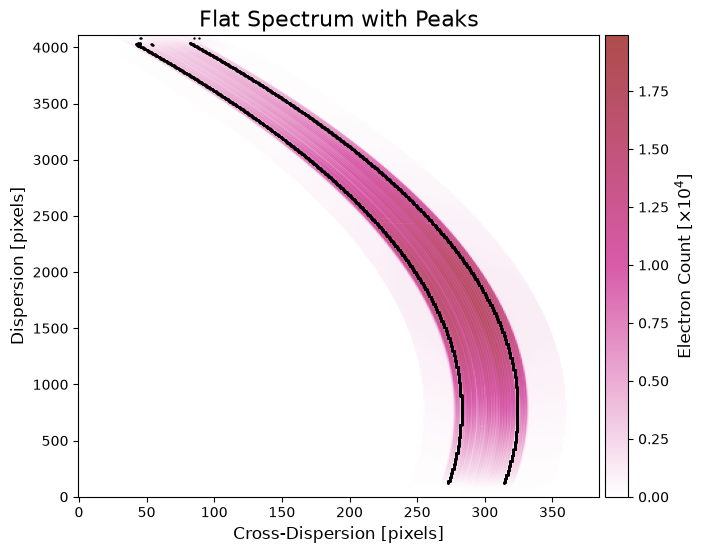

In [159]:
plt.figure(figsize=(8,6))

image = plt.imshow(flat*1e-4, cmap=cmap, origin="lower", aspect="auto", alpha=0.7) # plot full flat
plt.scatter(np.array(tramlines["left"]), np.array(tramlines["disp"]), c="black", s=0.5) # left tramline from identified peaks
plt.scatter(np.array(tramlines["right"]), np.array(tramlines["disp"]), c="black", s=0.5) # right tramline from identified peaks
plt.title("Flat Spectrum with Peaks", fontsize=16)
plt.xlabel("Cross-Dispersion [pixels]", fontsize=12)
plt.ylabel("Dispersion [pixels]", fontsize=12)
cbar = plt.colorbar(image, pad=0.01)
cbar.set_label(r"Electron Count [$\times 10^{4}$]", fontsize=12)

plt.show()

Use `scipy.interpolate.UnivariateSpline` to fit a functional form to the transposed tramline curves.

In [160]:
# remove any dispersion pixel spectrum with NaN tramlines before fitting function
tramlines = tramlines.dropna(axis=0, how="any")

# define numpy arrays
disp_pixel = np.array(tramlines["disp"])
left_tram = np.array(tramlines["left"])
right_tram = np.array(tramlines["right"])

# fit to function
left_spline = sp.interpolate.UnivariateSpline(disp_pixel, left_tram, s=1200) # very high s to minimise influence of noise
right_spline = sp.interpolate.UnivariateSpline(disp_pixel, right_tram, s=1200)

disp_smooth = np.arange(flat.shape[0])

left_smooth = np.array(left_spline(disp_smooth))
right_smooth = np.array(right_spline(disp_smooth))

Overplot smooth functions.

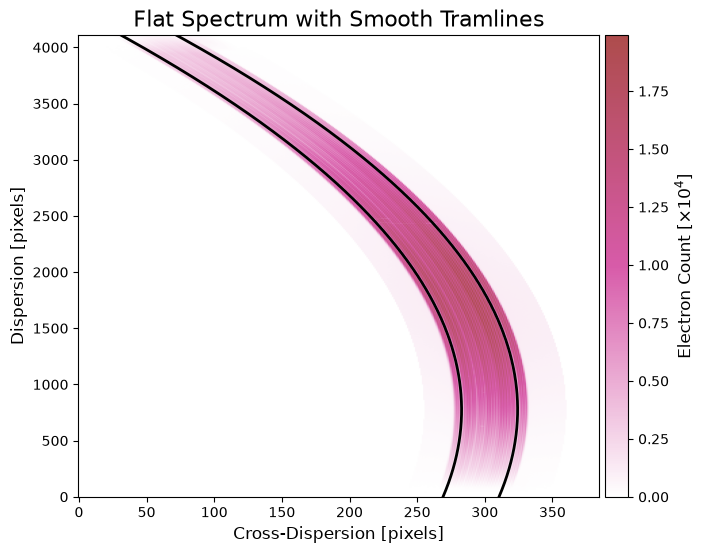

In [161]:
plt.figure(figsize=(8,6))

image = plt.imshow(flat*1e-4, cmap=cmap, origin="lower", aspect="auto", alpha=0.7) # plot full flat
plt.plot(left_smooth, disp_smooth, c="black", lw=2) # overplot left tramline
plt.plot(right_smooth, disp_smooth, c="black", lw=2) # overplot right tramline
plt.title("Flat Spectrum with Smooth Tramlines", fontsize=16)
plt.xlabel("Cross-Dispersion [pixels]", fontsize=12)
plt.ylabel("Dispersion [pixels]", fontsize=12)
cbar = plt.colorbar(image, pad=0.01)
cbar.set_label(r"Electron Count [$\times 10^{4}$]", fontsize=12)

plt.savefig("figures/q4a_tramlines.png", dpi=200) # save to figures/
plt.show()

## **Extract the Spectrum**

**Sum the counts between your tramlines to extract the flat-field and Moon spectra. Divide the Moon by the flat and plot the result as a function of dispersion pixel. Identify and indicate the pixels corresponding to the CaII lines at $8498$, $8542$, and $8662\,\AA$.**

Sum flat and moon spectrum.

In [162]:
# read-in to file (containing header/metadata)
moon_file = fits.open("data/q4_moon.fits")
# extract data
moon = np.array(moon_file[0].data)

xdisp_array = np.arange(flat.shape[1]) # x-dispersion axis

# create mask to only include values between the tramlines
mask = (
    (xdisp_array[np.newaxis,:] > left_smooth[:,np.newaxis]) & # project x-disp array and left tramline to 2D arrays
    (xdisp_array[np.newaxis,:] < right_smooth[:,np.newaxis])
)

# apply mask, does not require constant distance between tramlines
flat_array = np.where(mask, flat, np.nan) # return flat pixel value if mask=True, return NaN if mask=False
moon_array = np.where(mask, moon, np.nan)

# sum over x-disp axis ignoring NaNs (broadcast to all values outside tramlines)
flat_sum = np.nansum(flat_array, axis=1)
moon_sum = np.nansum(moon_array, axis=1)

Identify Ca II pixel ratios.

In [163]:
lo_ca = 8662 # long-lambda line, values taken from Q
mid_ca = 8542 # middle line
hi_ca = 8498 # short line
ratio = np.abs((hi_ca - mid_ca) / (mid_ca - lo_ca))
print(f"Short-lambda interval is {ratio:.1f} times long-lambda interval.")

Short-lambda interval is 0.4 times long-lambda interval.


Plot reduced spectrum.

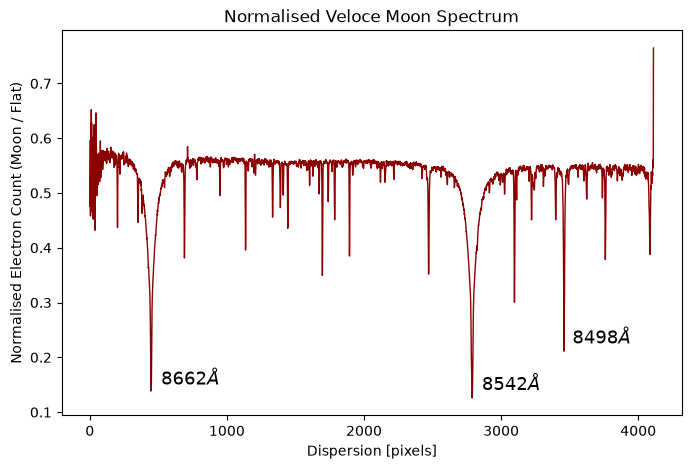

In [165]:
norm_spec = np.array(moon_sum / flat_sum) # normalised spectrum
disp_array = np.arange(flat.shape[0]) # dispersion axis

plt.figure(figsize=(8,5))

plt.plot(disp_array, norm_spec, c="darkred", lw=1) # normalised spectrum
plt.text(3520, 0.225, r"$8498\AA$", size=13, weight="bold") # label short-lambda
plt.text(2860, 0.14, r"$8542\AA$", size=13, weight="bold") # label middle
plt.text(520, 0.15, r"$8662\AA$", size=13, weight="bold") # label long
plt.title("Normalised Veloce Moon Spectrum")
plt.xlabel("Dispersion [pixels]")
plt.ylabel("Normalised Electron Count (Moon / Flat)")

plt.savefig("figures/q4b_spectrum.png", dpi=200) # save to figures/
plt.show()